In [1]:
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
import sqlite3 
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
import os   
import requests

C:\Users\vvija\AppData\Local\Temp\ipykernel_7176\530172210.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [2]:
load_dotenv(override=True)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="llama-3.3-70b-versatile", streaming=True)

In [3]:
loader=PyPDFLoader("lang.pdf")
docs = loader.load()
len(docs)

13

In [4]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)
len(chunks)

33

In [5]:
#Generate embedding and create a vector store using FAISS
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview")
vector_store =FAISS.from_documents(chunks, embeddings)


In [6]:
retriever = vector_store.as_retriever(search_type='similarity',search_kwargs={"k": 3})


In [7]:
retriever.invoke('wwho introducedlangchaion')


[Document(id='bd09af1f-095e-40a8-96ef-6532d03bee85', metadata={'producer': 'Pdftools SDK', 'creator': 'PyPDF', 'creationdate': '', 'moddate': '2025-07-28T07:20:30+00:00', 'source': 'lang.pdf', 'total_pages': 13, 'page': 11, 'page_label': '12'}, page_content='2 \n \n1.1 Introduction to LangChain \n1.1.1 Overview of the langchain ecosystem \nThe LangChain ecosystem is broad. Released in 2022, LangChain has become one of the \nfastest-growing frameworks for the building and scaling of large language model (LLM)-\nfocused applications. The LangChain ecosystem covers the development, deployment, \nand monitoring of LLM-powered applications as depicted in Figure 1.1.  \nConstituting the development layers are various interlinked LangChain packages and \ncomponents. These packages and components provide standardized interfaces for \nworking with models, prompts, memory, and tools.   \nSimilarly, LangGraph is an offshoot of the LangChain ecosystem that focuses on the \nbuilding of LLM-based ag

In [8]:
@tool
def rag_tool(query):
    """ 
    retrieve relevant information from the pdf document.
    Use this tool when user ask factual/conceptual questions that might be answered from the stored documents.
    """

    result = retriever.invoke(query)
    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
'query':query,
'context':context,
'metadata':metadata
    }
    

In [9]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)


In [10]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [11]:
def chat_node(state:ChatState):
    messages = state['messages']

    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [12]:
tool_node=ToolNode(tools)

In [13]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot=graph.compile()

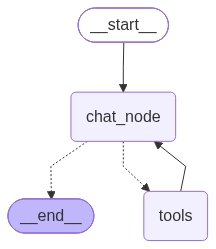

In [14]:
chatbot

In [15]:
# Chat node taking decision whether to use the tool or not based on the user query. If the user query is factual/conceptual and can be answered from the stored documents, it will use the RAG tool to retrieve relevant information from the PDF document. Otherwise, it will directly respond using the LLM.

result = chatbot.invoke({
    'messages':[
        HumanMessage(content="using the pdf nodes , explain about topics mentioned in the pdf list  with emoji?")
    ]
})

In [16]:
print(result['messages'][-1].content)

The PDF topics list with emoji explanation using pdf nodes is as follows:

1. **Working with chat prompt template** 📝: This topic explains how to use chat prompt templates to inject prompt engineering techniques into your application logic.
2. **Few-shot templates** 📊: This topic discusses how to work with few-shot templates, including static examples and dynamic examples.
3. **Handling dynamic examples** 🔄: This topic explains how to handle dynamic examples with few-shot templates.
4. **Document processing** 📄: This topic discusses how to process documents in the context of retrieval-augmented generation (RAG).
5. **Embedding model** 📈: This topic explains how to use embedding models in RAG.
6. **Vector stores** 🗂️: This topic discusses how to use vector stores in RAG.
7. **Evaluation metrics** 📊: This topic explains how to evaluate RAG and use evaluation metrics to identify the inadequacy of a RAG pipeline.
8. **LangChain** 🚀: This topic discusses how to use LangChain to build a ligh